## Импорт библиотек и загрузка данных

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('dataset/online_shoppers_intention.csv')

1. Общая информация. Название: Online Shoppers Purchasing Intention Dataset (Набор данных о намерении совершить покупку у онлайн-покупателей).
Целевая переменная: Атрибут Revenue (Выручка/Покупка). Он может использоваться в качестве метки класса для задач классификации.

2. Описание признаков

    1. Поведенческие метрики сессии (статистика посещения страниц). Эти признаки описывают действия пользователя во время текущей сессии на сайте. Значения обновляются в реальном времени по мере перемещения посетителя по страницам.
    - Administrative (Целочисленный) — количество страниц с административным (учетным) контентом, посещенных пользователем за сессию.
    - Administrative Duration (Вещественный) — общее время (в секундах), проведенное пользователем на страницах административного типа.
    - Informational (Целочисленный) — количество информационных страниц (например, справочная информация, контакты), посещенных за сессию.
    - Informational Duration (Вещественный) — общее время (в секундах), проведенное на информационных страницах.
    - Product Related (Целочисленный) — количество страниц, связанных с товарами (каталог, карточки товаров), посещенных за сессию.
    - Product Related Duration (Вещественный) — общее время (в секундах), проведенное на страницах, связанных с товарами.

    2. Метрики Google Analytics (показатели страниц входа/выхода). Эти признаки представляют стандартные метрики веб-аналитики для конкретных страниц сайта.
    - Bounce Rate (Вещественный) — показатель отказов для страницы. Процент посетителей, которые зашли на сайт с этой страницы и покинули его, не переходя на другие страницы и не инициируя другие запросы к серверу аналитики.
    - Exit Rate (Вещественный) — показатель выходов для страницы. Процент случаев, когда данная страница стала последней в сессии (пользователь покинул сайт именно с нее) от общего количества просмотров этой страницы.
    - Page Value (Вещественный) — ценность страницы. Средняя стоимость страницы, которую пользователь посетил перед тем, как совершить транзакцию (покупку).

3. Контекстные и временные признаки. Факторы, связанные со временем посещения и внешними событиями.

    - Special Day (Вещественный) — Близость к особой дате. Указывает насколько близко время посещения сайта к значимому событию (например, День матери, День святого Валентина), когда вероятность покупки возрастает.

        - Значение варьируется от 0 до 1.
        - Принимает ненулевые значения только в определенный период до события.
        - Достигает максимума (1) в день наибольшей покупательской активности (например, 8 февраля перед Днем святого Валентина).

    - Month (Категориальный) — месяц года (например, Jan, Feb, Mar...).

    - Weekend (Логический) — булево значение (True/False), указывающее, пришлось ли посещение на выходной день.

4. Технические и демографические признаки. Данные о пользователе и его устройстве.
    - Operating Systems (Целочисленный) — идентификатор операционной системы пользователя.
    - Browser (Целочисленный) — идентификатор браузера.
    - Region (Целочисленный) — идентификатор географического региона пользователя.
    - Traffic Type (Целочисленный) — идентификатор типа источника трафика (например, поисковые системы, прямая ссылка, реклама).
    - Visitor Type (Категориальный) — тип посетителя: Returning Visitor (вернувшийся) или New Visitor (новый).

5. Целевая переменная

    - Revenue (Логический) — флаг, была ли совершена транзакция (покупка) в данной сессии. Является целевой меткой для прогнозирования.



### 1. Общее исследование данных: проверить размеры таблицы, число столбцов, количество пропусков в столбцах (1 балл).

In [5]:
df.head(5)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
# 1.1. размер таблицы

print(f'число строк: {df.shape[0]}, число столбцов: {df.shape[1]}')

число строк: 12330, число столбцов: 18


In [7]:
#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12131 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  11839 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12231 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
# % нулевых значений
print(round(df.isnull().mean() * 100 , 1))

Administrative             0.0
Administrative_Duration    0.0
Informational              0.0
Informational_Duration     1.6
ProductRelated             0.0
ProductRelated_Duration    4.0
BounceRates                0.0
ExitRates                  0.8
PageValues                 0.0
SpecialDay                 0.0
Month                      0.0
OperatingSystems           0.0
Browser                    0.0
Region                     0.0
TrafficType                0.0
VisitorType                0.0
Weekend                    0.0
Revenue                    0.0
dtype: float64


### 2. Однофакторный анализ: по каждому столбцу посмотреть его распределение. Если есть пропуски и ошибочные значения - обработать их. Посмотреть связь с целевой переменной (3 балла).

In [9]:
# Есть ли в данных дубликаты

print(f'Количество дубликатов: {df.duplicated().sum()}')

Количество дубликатов: 109


In [10]:
# Удалим дубликаты

df.drop_duplicates(inplace=True)

In [11]:
# все столбцы
for item in df.columns:
    print(item)

Administrative
Administrative_Duration
Informational
Informational_Duration
ProductRelated
ProductRelated_Duration
BounceRates
ExitRates
PageValues
SpecialDay
Month
OperatingSystems
Browser
Region
TrafficType
VisitorType
Weekend
Revenue


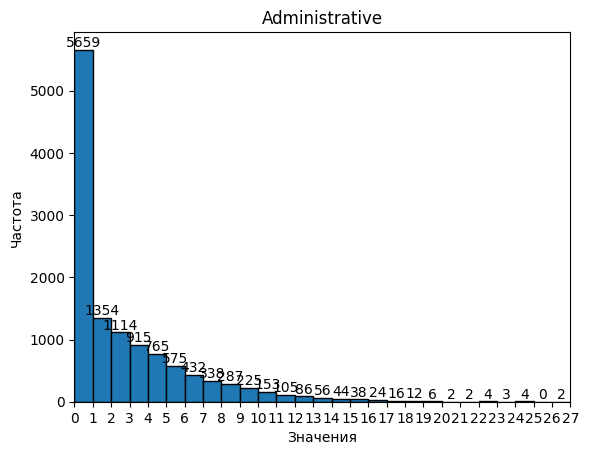

Administrative: max: 27, min: 0, median: 1.0
Administrative    5659
dtype: int64


In [12]:
# распределение по каждому столбцу
# Поведенческие метрики сессии 'Administrative', 'Administrative_Duration', 'Informational',
# 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration'

data_for_histogram = df[['Administrative']]


# Строим гистограмму
n, bins, patches = plt.hist(data_for_histogram, bins=27, edgecolor='black')


plt.xlim(0, 27)  # Устанавливаем пределы по оси X от 0 до 27
plt.xticks(np.arange(0, 28, 1))  # Устанавливаем деления через 1



# Добавляем подписи к каждому столбцу
for i, (count, patch) in enumerate(zip(n, patches)):
    height = patch.get_height()
    plt.text(patch.get_x() + patch.get_width()/2., height + 0.5,
             f'{int(count)}', ha='center', va='bottom')

plt.xlabel('Значения')

plt.ylabel('Частота')
plt.title('Administrative')



plt.show()

print(f"Administrative: max: {df['Administrative'].max()}, min: {df['Administrative'].min()}, median: {df['Administrative'].median()}")
print((data_for_histogram == 0).sum())


Administrative_Duration: max: 3398.75, min: 0.0, median: 9.0, percentile 0,9: 227.0


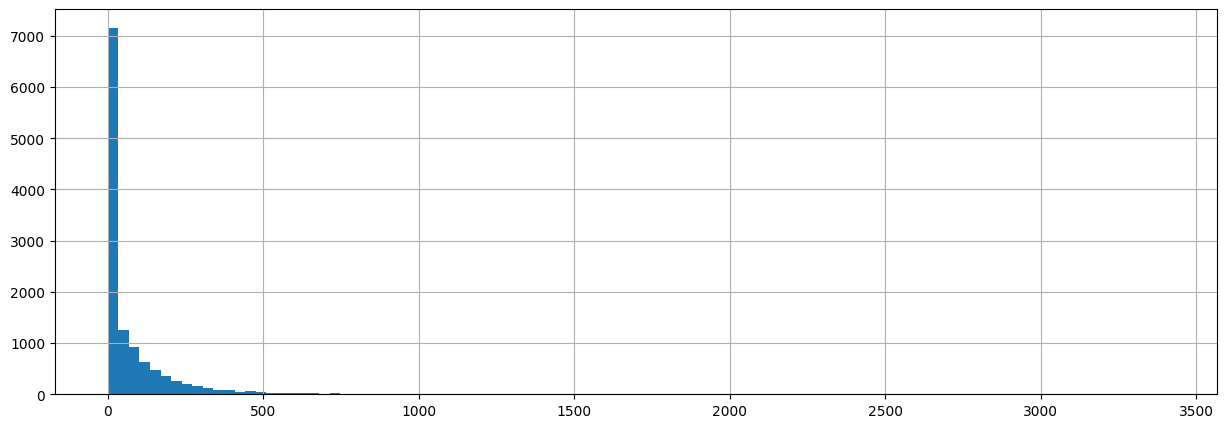

In [13]:

df['Administrative_Duration'].hist(bins=100, figsize=(15,5));

print(f"Administrative_Duration: max: {df['Administrative_Duration'].max()}, min: {df['Administrative_Duration'].min()}, median: {df['Administrative_Duration'].median()}, percentile 0,9: {df['Administrative_Duration'].quantile(0.9).__round__(0)}")

In [28]:
# в Informational_Duration и ProductRelated_Duration есть Null их нужно обработать (заменю медианой)

median_inf_duration = float(df['Informational_Duration'].median())
median_prod_rel_duration = float(df['ProductRelated_Duration'].median())

df.fillna({'Informational_Duration': median_inf_duration}, inplace=True )
df.fillna({'ProductRelated_Duration': median_prod_rel_duration}, inplace=True )

Informational: max: 24, min: 0, median: 0.0
Informational_Duration: max: 2549.375, min: 0.0, median: 0.0


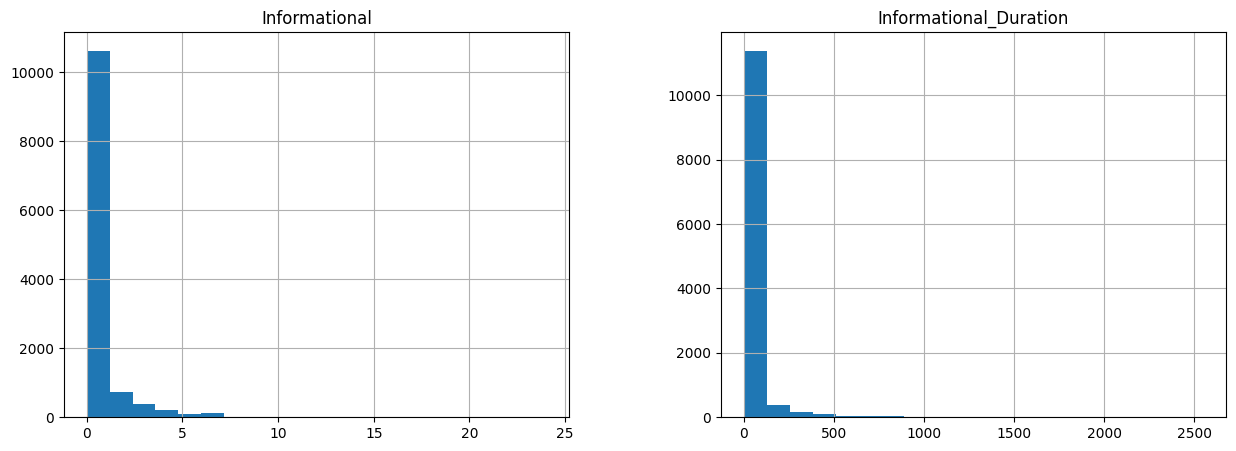

In [26]:
# распределение по каждому столбцу

df[['Informational', 'Informational_Duration']].hist(bins=20, figsize=(15,5));
print(f"Informational: max: {df['Informational'].max()}, min: {df['Informational'].min()}, median: {df['Informational'].median()}")
print(f"Informational_Duration: max: {df['Informational_Duration'].max()}, min: {df['Informational_Duration'].min()}, median: {df['Informational_Duration'].median()}")

ProductRelated: max: 705, min: 0, median: 18.0
ProductRelated_Duration: max: 63973.52223, min: 0.0, median: 606.28333335


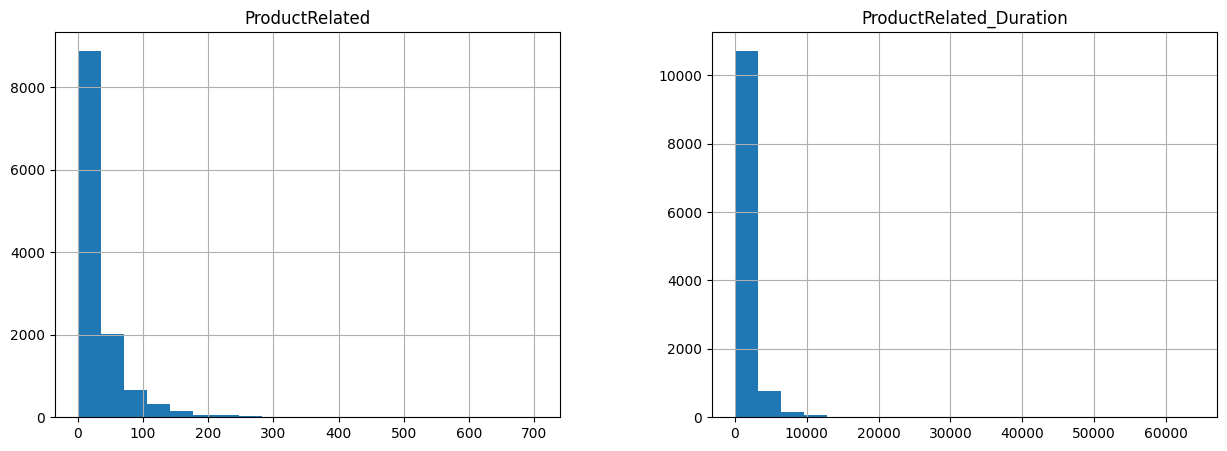

In [15]:
# распределение по каждому столбцу

df[['ProductRelated', 'ProductRelated_Duration']].hist(bins=20, figsize=(15,5));
print(f"ProductRelated: max: {df['ProductRelated'].max()}, min: {df['ProductRelated'].min()}, median: {df['ProductRelated'].median()}")
print(f"ProductRelated_Duration: max: {df['ProductRelated_Duration'].max()}, min: {df['ProductRelated_Duration'].min()}, median: {df['ProductRelated_Duration'].median()}")

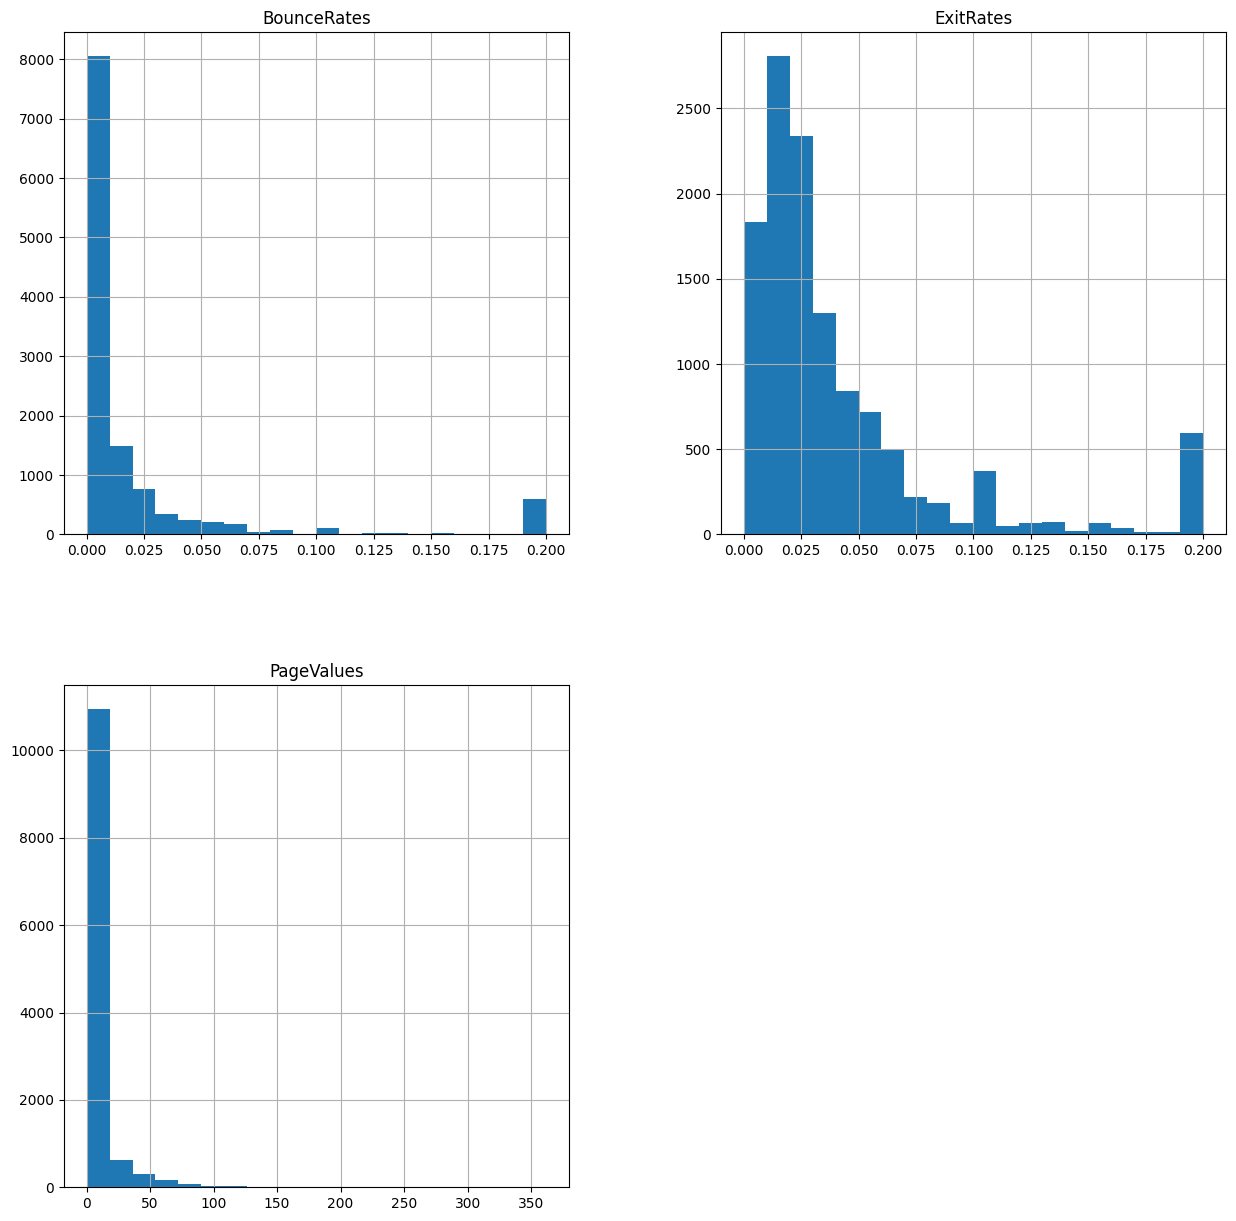

In [16]:
# распределение по каждому столбцу
# Метрики Google Analytics  'BounceRates', 'ExitRates', 'PageValues'

df[['BounceRates', 'ExitRates', 'PageValues']].hist(bins=20, figsize=(15,15));

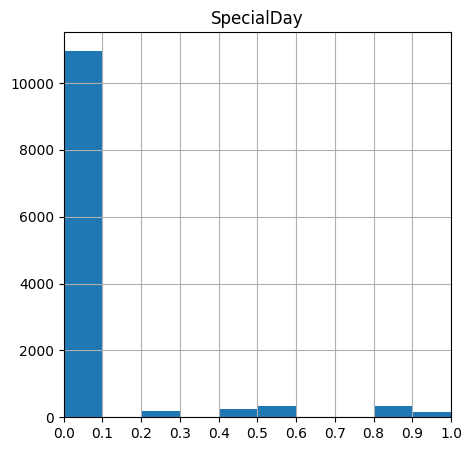

In [17]:
# распределение по каждому столбцу
# Контекстные и временные признаки 'SpecialDay', 'Month', 'Weakend'

df[['SpecialDay']].hist(bins=10, figsize=(5,5));
plt.xlim(0, 1)  # Устанавливаем пределы по оси X от 0 до 1
plt.xticks(np.arange(0, 1.1, 0.1))  # Устанавливаем деления через 0.1
plt.show()

In [21]:
df['Month'] = df['Month'].replace('aug', 'Aug')

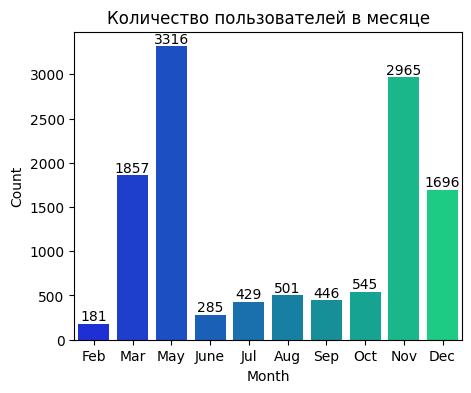

,Month,Count,Month_Num
2,Feb,181,2
5,Mar,1857,3
6,May,3316,5
4,June,285,6
3,Jul,429,7
0,Aug,501,8
9,Sep,446,9
8,Oct,545,10
7,Nov,2965,11
1,Dec,1696,12


In [22]:
month_count = df.groupby('Month').agg(Count = ('Month', 'count')).reset_index()

# добавляем номер месяца

month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12, 'aug': 8
}

month_count['Month_Num'] = month_count['Month'].map(month_map)
month_count.sort_values(by='Month_Num', ascending=True, inplace=True) # сортируем по номеру месяца


plt.figure(figsize=(5,4))

ax = sns.barplot(x='Month', y='Count', data = month_count, hue='Month', palette='winter') 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('Количество пользователей в месяце')
plt.show();
month_count

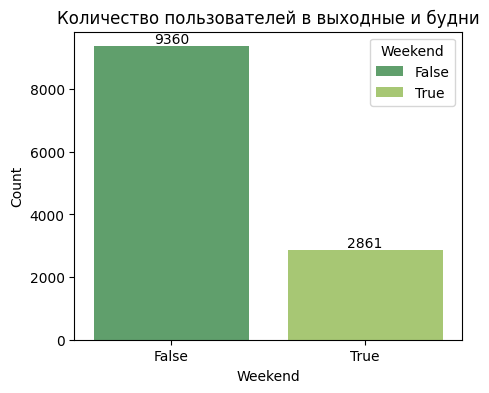

   Weekend  Count
0    False   9360
1     True   2861


In [23]:
weekend_count = df.groupby('Weekend').agg(Count = ('Weekend', 'count')).reset_index()

plt.figure(figsize=(5,4))

ax = sns.barplot(x='Weekend', y='Count', data = weekend_count, hue='Weekend', palette='summer') 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('Количество пользователей в выходные и будни')
plt.show();

print(weekend_count)

In [ ]:
# 4. Технические и демографические признаки. Данные о пользователе и его устройстве.
    # - Operating Systems (Целочисленный) — идентификатор операционной системы пользователя.
    # - Browser (Целочисленный) — идентификатор браузера.
    # - Region (Целочисленный) — идентификатор географического региона пользователя.
    # - Traffic Type (Целочисленный) — идентификатор типа источника трафика (например, поисковые системы, прямая ссылка, реклама).
    # - Visitor Type (Категориальный) — тип посетителя: Returning Visitor (вернувшийся) или New Visitor (новый).

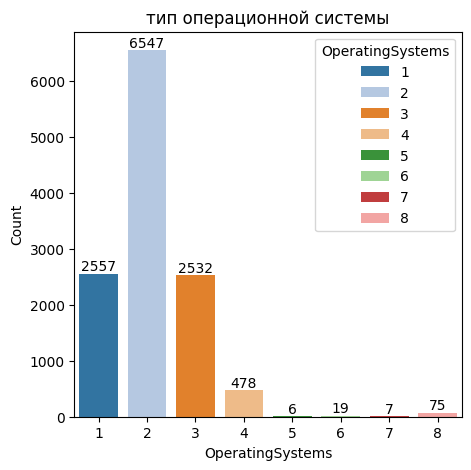

In [19]:
# - Operating Systems (Целочисленный) — идентификатор операционной системы пользователя.
os_count = df.groupby('OperatingSystems').agg(Count = ('OperatingSystems', 'count')).reset_index()
plt.figure(figsize=(5,5))

ax = sns.barplot(x='OperatingSystems', y='Count', data = os_count, hue='OperatingSystems', palette='tab20') 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('тип операционной системы')
plt.show();

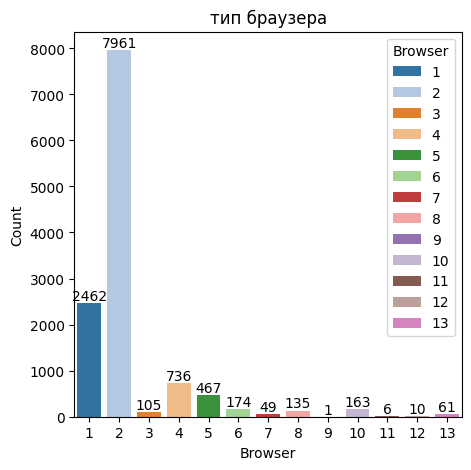

In [221]:
# - Browser (Целочисленный) — идентификатор браузера.

browser_count = df.groupby('Browser').agg(Count = ('Browser', 'count')).reset_index()
plt.figure(figsize=(5,5))

ax = sns.barplot(x='Browser', y='Count', data = browser_count, hue='Browser', palette='tab20') 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('тип браузера')
plt.show();

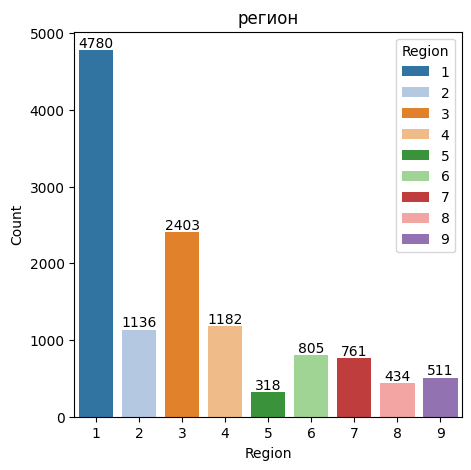

In [220]:
# - Region (Целочисленный) — идентификатор географического региона пользователя.

region_count = df.groupby('Region').agg(Count = ('Region', 'count')).reset_index()
plt.figure(figsize=(5,5))

ax = sns.barplot(x='Region', y='Count', data = region_count, hue='Region', palette='tab20') 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('регион')
plt.show();

In [222]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


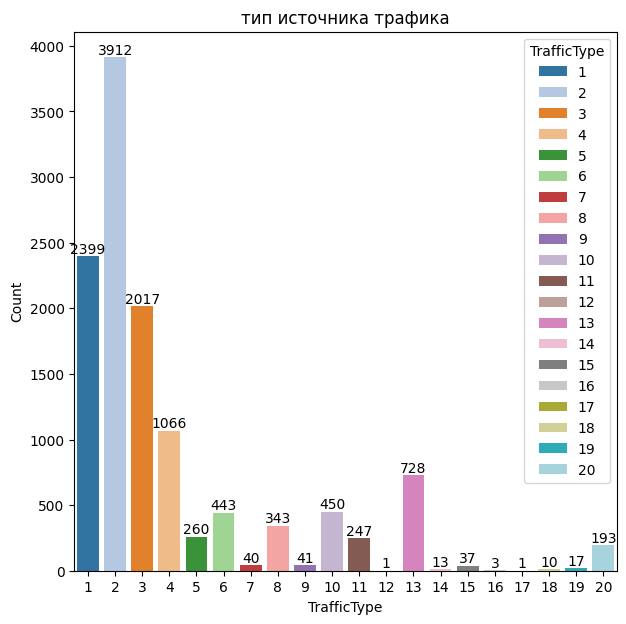

In [20]:
# Traffic Type (Целочисленный) — идентификатор типа источника трафика (например, поисковые системы, прямая ссылка, реклама).


traffic_count = df.groupby('TrafficType').agg(Count = ('TrafficType', 'count')).reset_index()
plt.figure(figsize=(7,7))

ax = sns.barplot(x='TrafficType', y='Count', data = traffic_count, hue='TrafficType', palette="tab20") 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('тип источника трафика')
plt.show();


In [30]:
df.head(1)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False


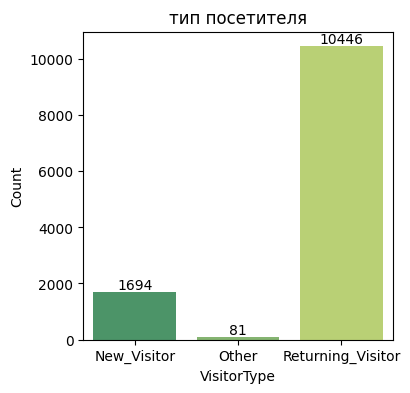

In [31]:
# - Visitor Type (Категориальный) — тип посетителя: Returning Visitor (вернувшийся) или New Visitor (новый).
visitor_count = df.groupby('VisitorType').agg(Count = ('VisitorType', 'count')).reset_index()
plt.figure(figsize=(4,4))

ax = sns.barplot(x='VisitorType', y='Count', data = visitor_count, hue='VisitorType', palette="summer") 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('тип посетителя')
plt.show();

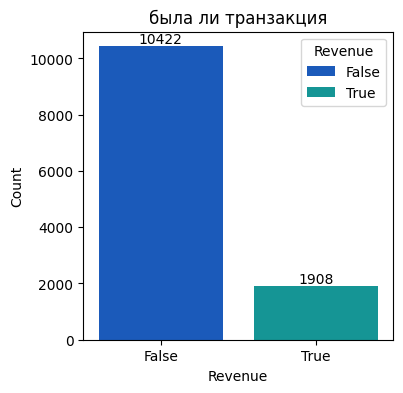

In [239]:
# Revenue (Логический) — флаг, была ли совершена транзакция (покупка) в данной сессии. Является целевой меткой для прогнозирования.


revenue_count = df.groupby('Revenue').agg(Count = ('Revenue', 'count')).reset_index()
plt.figure(figsize=(4,4))

ax = sns.barplot(x='Revenue', y='Count', data = revenue_count, hue='Revenue', palette="winter") 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('была ли транзакция')
plt.show();

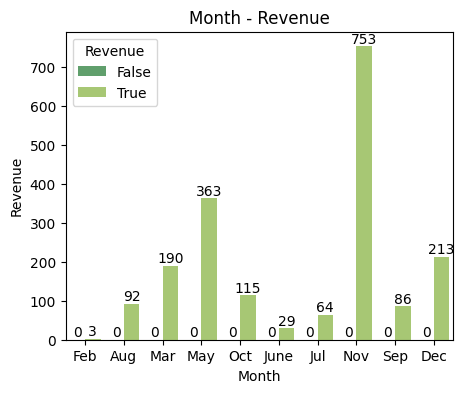

In [ ]:
# Посмотреть связь с целевой переменной


plt.figure(figsize=(5,4))

ax = sns.barplot(x='Month', y='Revenue', data = df, hue='Revenue', palette='summer', estimator='sum') # выводит медианное значение по категориям (можно среднее)

# Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('Month - Revenue')
plt.show();

# Максимальное количество транзакций в ноябре, затем в мае

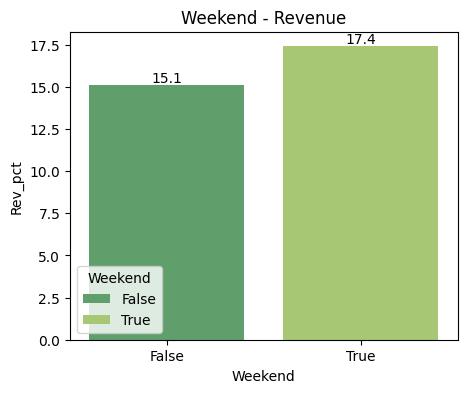

In [ ]:
# Посмотреть связь с целевой переменной

weekend_count = df.groupby('Weekend').agg(Count = ('Weekend', 'count'), Revenue = ('Revenue', 'sum')).reset_index()
weekend_count['Rev_pct'] = round((weekend_count['Revenue'] / weekend_count['Count']) * 100, 1)

plt.figure(figsize=(5,4))

ax = sns.barplot(x='Weekend', y='Rev_pct', data = weekend_count, hue='Weekend', palette='summer', estimator='sum') # выводит медианное значение по категориям (можно среднее)

# Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('Weekend - Revenue')
plt.show();

# В выходные % продаж больше

# 3. Построить матрицу корреляций (или ее аналог для категориальных признаков): использовать корреляции, тест χ2χ2, ANOVA (2 балла).

<Axes: >

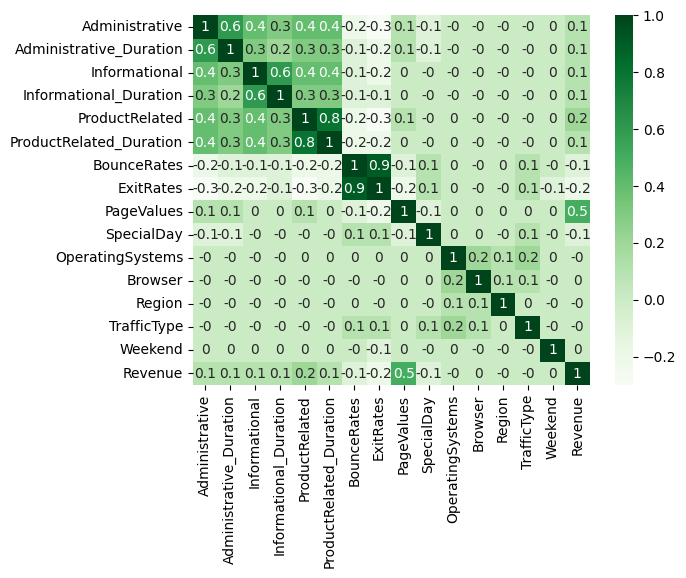

In [58]:
# Построить матрицу корреляций 

corr = df.corr(numeric_only=True) # матрица корреляций
sns.heatmap(corr.round(1), cmap="Greens", annot=True) # heatmap с помошью библиотеки seaborn

# Наибольшая корреляция с PageValues

In [60]:
!pip install association-metrics -q

In [ ]:
import association_metrics as am

df_cat = df.apply(lambda x: x.astype("category") if x.dtype == "object" or x.dtype == "bool" else x) # меняем категорию данных с object и bool на category т.к. am воспринимает только тип category


cramersv = am.CramersV(df_cat)

cramersv.fit()


c:\Users\Stanislav\Yandex.Disk\Обучение\260117 Разведочный анализ данных\4.1 Инструменты анализа данных. Polars versus Pandas\.venv\lib\site-packages\association_metrics\categorical.py:100: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.

,Month,VisitorType,Weekend,Revenue
Month,1.000000,0.137251,0.064912,0.175457
VisitorType,0.137251,1.000000,0.053418,0.103550
Weekend,0.064912,0.053418,1.000000,0.027858
Revenue,0.175457,0.103550,0.027858,1.000000


In [73]:
# Anova
from scipy.stats import f_oneway


Data = []

for c1 in df_cat.columns:

    for c2 in df_cat.columns:
        if df_cat[c1].dtype == 'category' and df_cat[c2].dtype != 'category':
           
            CategoryGroupLists = df_cat.groupby(c1)[c2].apply(list)
            AnovaResults = f_oneway(*CategoryGroupLists)

            if AnovaResults[1] >= 0.05:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'No'})
            else:
                Data.append({'Category' : c1, 'Numerical' : c2, 'Is correlated' : 'Yes'})

AnovaRes = pd.DataFrame.from_dict(Data)
AnovaRes

C:\Users\Stanislav\AppData\Local\Temp\ipykernel_12140\308228321.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  CategoryGroupLists = df_cat.groupby(c1)[c2].apply(list)


,Category,Numerical,Is correlated
0,Month,Administrative,Yes
1,Month,Administrative_Duration,Yes
2,Month,Informational,Yes
3,Month,Informational_Duration,Yes
4,Month,ProductRelated,Yes
5,Month,ProductRelated_Duration,Yes
6,Month,BounceRates,Yes
7,Month,ExitRates,Yes
8,Month,PageValues,Yes
9,Month,SpecialDay,Yes


## 4. Провести анализ целевой переменной - на какое распределение больше всего похожа ее гистограмма? Какие проблемы в связи с этим могут возникнуть при обучении моделей? (1 балл)

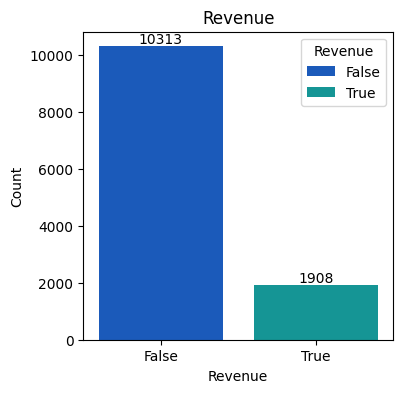

In [78]:
# Revenue (Логический) — флаг, была ли совершена транзакция (покупка) в данной сессии. Является целевой меткой для прогнозирования.


revenue_count = df.groupby('Revenue').agg(Count = ('Revenue', 'count')).reset_index()
plt.figure(figsize=(4,4))

ax = sns.barplot(x='Revenue', y='Count', data = revenue_count, hue='Revenue', palette="winter") 

# # Добавляем подписи значений на столбцах
for container in ax.containers:
    ax.bar_label(container)

plt.title('Revenue')
plt.show();

# Т.к. целевая переменная принимает всего 2-а значение то распределение Бернулли
# Потенциальные проблемы при обучении модели:
    # 1. Дисбаланс классов (модель может обучиться на мажоритарном классе)
    # 2. Неверный выбор метрики (высокая точность не гарантирует что модель нашла редкие события)



# 5. Увеличить размер данных простым дублированием до 1_000_000 строк в датасете. Провести сравнение скорости работы Pandas и Polars на увеличенном датасете по параметрам: 
# - загрузка данных (1 балл)
# - фильтрация данных (1 балл)
# - агрегация данных (1 балл)

In [80]:
df.shape

(12221, 18)

In [118]:
df_big = df.copy()

for i in range(100):
    df_big = pd.concat([df_big, df])

df_big.reset_index()

,index,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1234316,12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
1234317,12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
1234318,12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
1234319,12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


In [119]:
df_big = df_big.iloc[:-234321]

In [121]:
df_big.shape

(1000000, 18)

In [122]:
df_big.to_csv("shoppers_big.csv", index=False)

In [123]:
!pip install polars

import polars as pl

print(pl.__version__)

1.38.1


### 1. загрузка данных (1 балл)

In [124]:
%%time

df_pl = pl.read_csv("shoppers_big.csv")

CPU times: total: 906 ms
Wall time: 158 ms


In [125]:
%%time

df = pd.read_csv("shoppers_big.csv")

CPU times: total: 1.31 s
Wall time: 1.38 s


полярис быстрее

### 2. фильтрация данных (1 балл)


In [126]:
%%time

df_pl[['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']]

CPU times: total: 15.6 ms
Wall time: 34.4 ms


Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
i64,f64,i64,f64,i64,f64
0,0.0,0,0.0,1,0.0
0,0.0,0,0.0,2,64.0
0,0.0,0,0.0,1,0.0
0,0.0,0,0.0,2,2.666667
0,0.0,0,0.0,10,627.5
…,…,…,…,…,…
1,4.0,0,0.0,39,983.138889
0,0.0,2,1368.0,26,650.808333
1,65.5,0,0.0,2,99.0


In [127]:
%%time

df[['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration']]

CPU times: total: 15.6 ms
Wall time: 51.2 ms


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration
0,0,0.00,0,0.0,1,0.000000
1,0,0.00,0,0.0,2,64.000000
2,0,0.00,0,0.0,1,0.000000
3,0,0.00,0,0.0,2,2.666667
4,0,0.00,0,0.0,10,627.500000
...,...,...,...,...,...,...
999995,1,4.00,0,0.0,39,983.138889
999996,0,0.00,2,1368.0,26,650.808333
999997,1,65.50,0,0.0,2,99.000000
999998,5,142.75,0,0.0,76,1523.578030


полярис быстрее

### 3. Агрегация данных (1 балл)

In [128]:
%%time

df_pl.group_by('Month').agg([pl.mean('Administrative_Duration'), pl.max('Informational_Duration')])

CPU times: total: 219 ms
Wall time: 96.1 ms


Month,Administrative_Duration,Informational_Duration
str,f64,f64
"""Sep""",109.327675,1655.4
"""Feb""",17.152072,120.0
"""Oct""",126.137493,1657.3
"""June""",59.752366,985.483333
"""Aug""",101.352853,1165.166667
"""Nov""",91.482506,1830.5
"""May""",70.086563,2050.433333
"""Dec""",79.771597,2549.375
"""Mar""",72.900817,1467.0


In [129]:
%%time

df.groupby('Month').agg({'Administrative_Duration' : 'mean', 'Informational_Duration' : 'max'})

CPU times: total: 62.5 ms
Wall time: 69.9 ms


,Administrative_Duration,Informational_Duration
Month,,
Aug,101.352853,1165.166667
Dec,79.771597,2549.375000
Feb,17.152072,120.000000
Jul,79.036650,2252.033333
June,59.752366,985.483333
Mar,72.900817,1467.000000
May,70.086563,2050.433333
Nov,91.482506,1830.500000
Oct,126.137493,1657.300000


пандас быстрее